In [1]:
import torch
from utils import do_2D_pca, load_image, resize_crop
import torch.nn.functional as F
import matplotlib.pyplot as plt
from functorch import vmap
from vit_wrapper import (
    PretrainedViTWrapper,
    MODEL_MAP,
    FeatureType,
    MODEL_LIST,
)
import numpy as np
from probe import probe

/home/ab_aimd_anja_20884/anaconda3/envs/moritz_eng_new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## functions

In [2]:
def normalize(t_tens):
    return (t_tens - t_tens.min())/(t_tens.max() - t_tens.min())

In [3]:
import torch
import math

def translate_tensor_wrap(x: torch.Tensor, step_x: int = 0, step_y: int = 0) -> torch.Tensor:
    """
    Circularly translate tensor using wrap boundary conditions.

    Args:
        x: Tensor of shape (B, C, H, W)
        step_x: horizontal shift in pixels; positive -> right
        step_y: vertical shift in pixels; positive -> down

    Returns:
        Tensor of same shape (B, C, H, W) translated with wrap (circular) boundary.
    """
    
    if not isinstance(step_x, (int,)) or not isinstance(step_y, (int,)):
        #print(type(step_x), type(step_y))
        raise ValueError("translate_tensor_wrap expects integer step_x and step_y for exact circular wrap.")
    # torch.roll uses order: dims (H dim index 2, W dim index 3)
    return torch.roll(x, shifts=(step_y, step_x), dims=(2, 3))


def revert_translation_wrap(feat: torch.Tensor, step_x: int = 0, step_y: int = 0, scale_factor: int = 14,
                            require_exact_division: bool = True) -> torch.Tensor:
    """
    Revert an image-space integer translation on a feature map using circular wrapping.
    The original translation is in *image pixels*; we convert to feature pixels by dividing by scale_factor.

    Args:
        feat: Tensor of shape (B, C, Hf, Wf)  (e.g. (1, 384, H//14, W//14))
        step_x: original image translation (pixels, int)
        step_y: original image translation (pixels, int)
        scale_factor: integer scaling between image and feature map spatial dims (e.g. 14)
        require_exact_division: if True, require that step_x/scale_factor and step_y/scale_factor are integers.
                                If False, the feature shift will be rounded to nearest integer.

    Returns:
        Tensor of same shape (B, C, Hf, Wf) where the translation is reverted using circular wrap.
    """
    if not isinstance(step_x, (int,)) or not isinstance(step_y, (int,)):
        raise ValueError("step_x and step_y must be integers (image pixels).")

    # convert to feature-map pixels (float)
    fx = step_x / float(scale_factor)
    fy = step_y / float(scale_factor)

    # check divisibility if requested
    if require_exact_division:
        if not fx.is_integer() or not fy.is_integer():
            raise ValueError(f"Translation {step_x},{step_y} not divisible by scale_factor={scale_factor}. "
                             "Resulting feature shift would be fractional. "
                             "Set require_exact_division=False to allow rounding.")
        fx = int(fx)
        fy = int(fy)
    else:
        # round to nearest integer feature shift
        fx = int(round(fx))
        fy = int(round(fy))

    # to revert the original translation we roll in the opposite direction
    return torch.roll(feat, shifts=(-fy, -fx), dims=(2, 3))


In [4]:
def translate_14(img, x_step, y_step, plot:bool=False):
    '''
    step refers to the step in the feature tensor
    '''
    if isinstance(x_step, np.ndarray) and isinstance(x_step, np.ndarray):
        x_step, y_step = x_step*14, y_step*14
        tensor_list = []
        for x_step_, y_step_ in zip(x_step, y_step):
            tensor_list.append(translate_tensor_wrap(img, step_x=int(x_step_), step_y=int(y_step_)))
        #tensor_list.reverse()
        batched_tensor = torch.concat(tensor_list, dim=0)
        #print(f"{batched_tensor.shape=}")

        #inference
        with torch.inference_mode(): 
            pred = model.forward_features(batched_tensor.float(), make_2D=True)#.to("cpu").to("cuda")
        #print(f"{pred.shape}")

        res_list = []
        for x_step_, y_step_, pred_ in zip (x_step, y_step, pred):
            res_list.append(revert_translation_wrap(pred_.unsqueeze(0), step_x=int(x_step_), step_y=int(y_step_), scale_factor=14, require_exact_division=False))#.detach().cpu().squeeze().transpose(2, 0).float()
        
        batched_res = torch.concat(res_list, dim=0)
        return batched_res
    else:
        x_step, y_step = x_step*14, y_step*14
        t_tens = translate_tensor_wrap(img, step_x=x_step, step_y=y_step)#.to("cpu")
        #print(t_tens.shape)

        # inference
        with torch.inference_mode(): 
            pred = model.forward_features(t_tens.float(), make_2D=True)#.to("cpu").to("cuda")
        #print(f"{pred.shape}")

        un_ten = revert_translation_wrap(pred, step_x=x_step, step_y=y_step, scale_factor=14, require_exact_division=False)#.detach().cpu().squeeze().transpose(2, 0).float()
    
        if plot:
            plt_t_tens= t_tens.clone().detach().cpu().squeeze().transpose(2, 0).float()
            fig, ax = plt.subplots(1, 4, figsize=(15, 5))
            ax[0].imshow(normalize(img.detach().cpu().squeeze().transpose(2, 0).float()))
            ax[0].set_title("orig image")
            ax[1].imshow(normalize(plt_t_tens))
            ax[1].set_title("translated image")
            ax[2].imshow(do_2D_pca(pred.squeeze(), post_norm="minmax"))
            ax[2].set_title("translated_prediction")
            ax[3].imshow(do_2D_pca(un_ten.squeeze(), post_norm="minmax"))
            ax[3].set_title("untranslated prediction image")

        return un_ten


import time
def batched_translate_and_predict(img, x_step, y_step, scale_factor=14, device="cuda"):
    # ensure img has batch dim
    if img.dim() == 3:
        img = img.unsqueeze(0)   # (1, C, H, W)
    # move once to device
    img = img.to(device)

    # convert steps to ints and scale if needed
    x_steps = [int(x * 14) for x in x_step]  # or x_step already scaled
    y_steps = [int(y * 14) for y in y_step]

    start = time.perf_counter()
    # Build batched translated tensor (on device)
    translated_list = [torch.roll(img, shifts=(ys, xs), dims=(2, 3)) 
                       for xs, ys in zip(x_steps, y_steps)]
    #print("time for rolling =", time.perf_counter() - start)
    batched_tensor = torch.cat(translated_list, dim=0)   # shape (N, C, H, W)

    # Inference in single batch on GPU
    start = time.perf_counter()
    with torch.inference_mode():
        pred = model.forward_features(batched_tensor.float(), make_2D=True)  # stays on device
    print(pred.shape)
    #print("time for inference =", time.perf_counter() - start)

    # Revert translations on the predictions (inverse roll)
    # assume pred shape (N, featC, featH, featW)
    start = time.perf_counter()
    reverted_list = [torch.roll(p.unsqueeze(0), shifts=(-ys//14, -xs//14), dims=(2, 3))
                     for p, xs, ys in zip(pred, x_steps, y_steps)]
    batched_res = torch.cat(reverted_list, dim=0)  # (N, featC, featH, featW)
    #print("time for unrolling =", time.perf_counter() - start)

    # optional: move to cpu if you need
    return batched_res

In [5]:
def translate(img, factor=4):
    from tqdm import tqdm

    from itertools import batched
    img_size=img.shape[-1]

    x = np.array(range(1, img_size//(factor*14)))*factor

    y = x.copy()
    x_steps, y_steps = np.meshgrid(x, y)
    #print()

    x_batches = list(batched(x_steps.flatten(), x.shape[0]))
    y_batches = list(batched(y_steps.flatten(), x.shape[0]))

    #print(x_batches, y_batches)



    res = torch.zeros((1, 384, img_size//14, img_size//14)).to("cuda")
    # for x, y in tqdm(zip(x_batches, y_batches)):
    #     #print(res.shape, translate_14(img, x_step=int(x), y_step=int(y)).)
    #     start = time.perf_counter()        
    #     res = batched_translate_and_predict(img, x_step=np.array(x), y_step=np.array(y)).sum(0, keepdim=True)
    #     #print("time until_res_add", time.perf_counter() - start)
    #     #print(intermediate.shape)

    for x, y in tqdm(zip(x_steps.flatten().astype(int), y_steps.flatten().astype(int))):
        #print(res.shape, translate_14(img, x_step=int(x), y_step=int(y)).)
        res += translate_14(img, x_step=int(x), y_step=int(y))#.cpu()
    mean_res = res/x_steps.flatten().shape[0]
    return mean_res


## notebook

In [6]:
model = PretrainedViTWrapper(MODEL_LIST[1], add_flash_attn=False, device="cuda")

In [7]:
img_size = 224

In [8]:
img = load_image("images/default_image.jpg", resize_crop((img_size, img_size),(img_size, img_size)))[0]

In [9]:
normal = translate(img, factor=1)
flipped = translate(img.flip(0, 3), factor=1)
flip2 = translate(img.flip(0,2), factor=1)
flip3 = translate(img.flip(0,3).flip(0,2), factor=1)
mean = (normal + flipped.flip(0,3) + flip2.flip(0,2) + flip3.flip(0,2).flip(0,3)) / 4

225it [00:01, 133.67it/s]
225it [00:01, 149.01it/s]
225it [00:01, 146.06it/s]
225it [00:01, 150.72it/s]


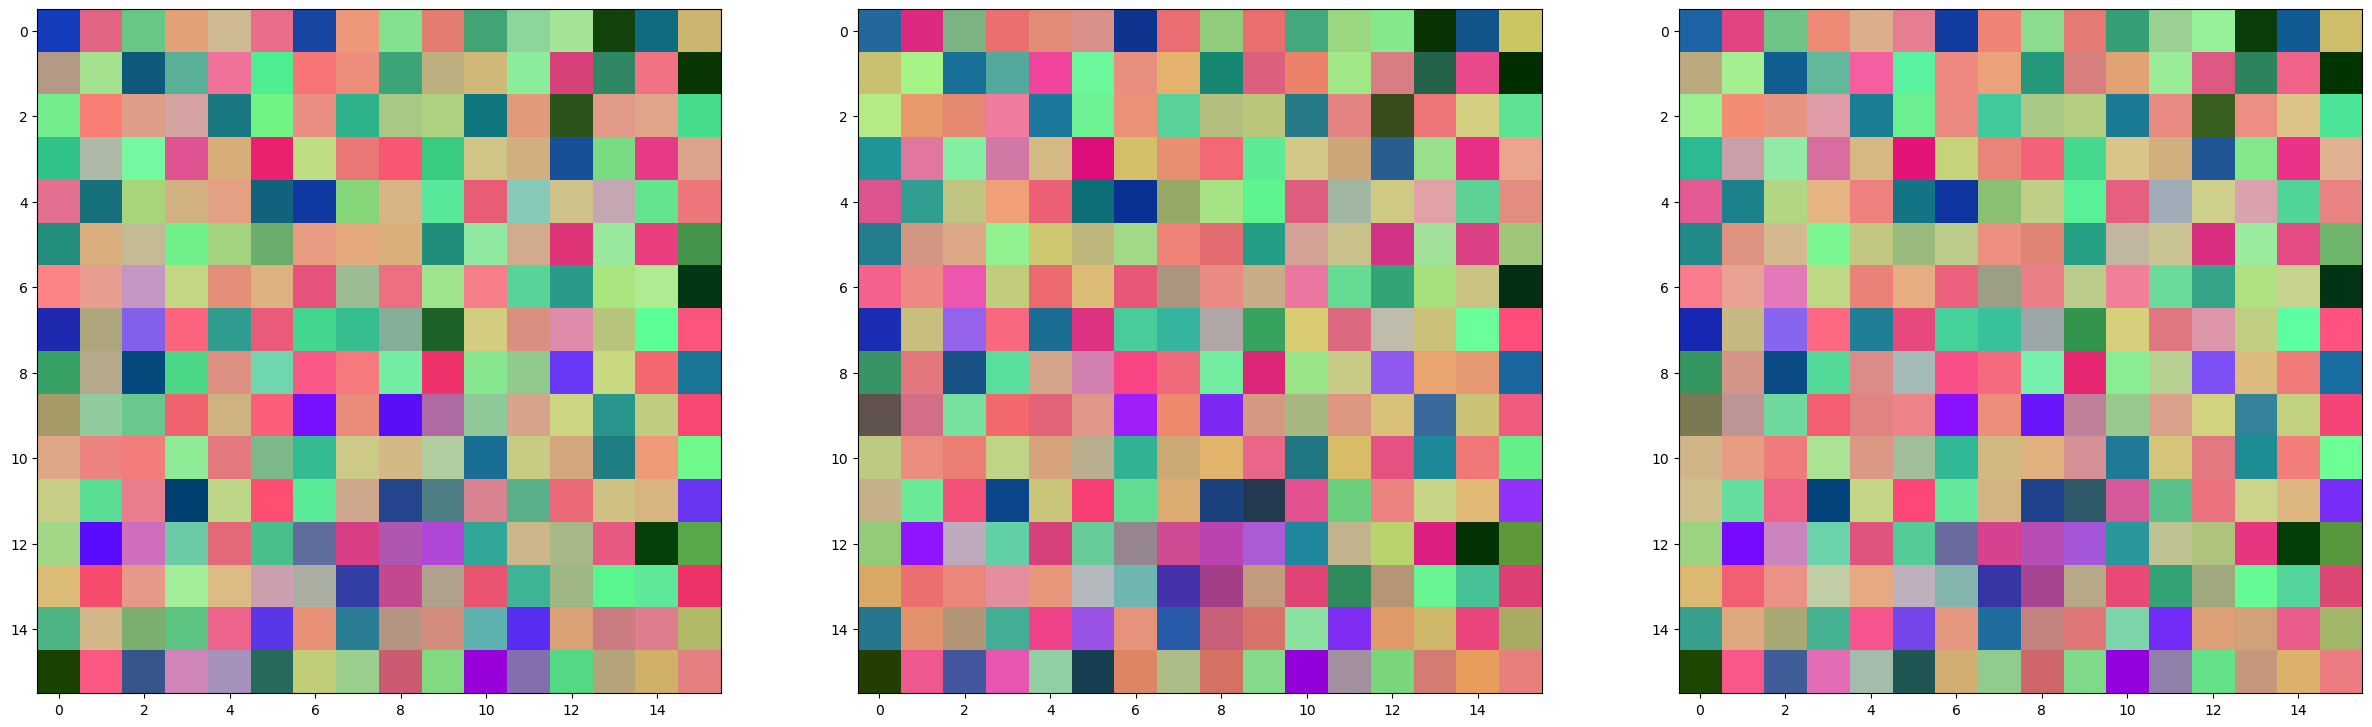

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(30,10))
ax[0].imshow(do_2D_pca(normal.squeeze(), post_norm="minmax"))
ax[1].imshow(do_2D_pca(flip3.flip(0,2).flip(0,3).squeeze(), post_norm="minmax"))
ax[2].imshow(do_2D_pca(mean.squeeze(), post_norm="minmax"))

(384, 16, 16)
(384, 16, 16)
(384, 16, 16)
(384, 16, 16)
(384, 16, 16)


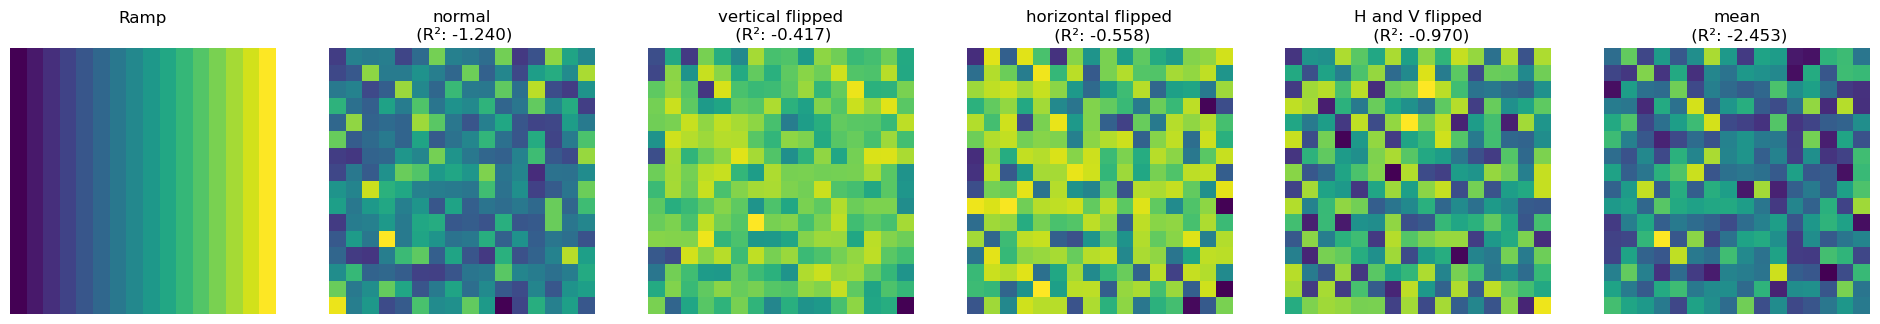

In [11]:
probe([normal, flipped, flip2, flip3, mean], [False]*5, ["normal", "vertical flipped", "horizontal flipped", "H and V flipped", "mean"], "lr")

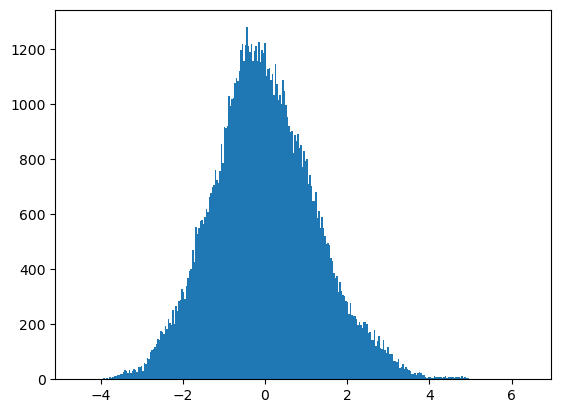

In [12]:
_ =plt.hist(normal.cpu().flatten(), bins=300)

In [13]:
preds_ = [model.forward_features(img.float(), make_2D=True),translate(img, factor=1),translate(img, factor=2), translate(img, factor=3), translate(img, factor=4), translate(img, factor=8)]
#preds = [tensor for pred in preds_ for tensor in (pred, pred.clone())]
#titles = ["DinoV2", "DinoV2 chnl blk", "fac 2" ,"fac 2 chnl blk", "fac 4" ,"fac 4 chnl blk", "fac 8", "fac 8 chnl blk", "fac 12", "fac 12 chnl blk"]
titles = ["DinoV2", "1", "2", "3", "4", "8"]
blanked = [False, True]*5

225it [00:01, 122.79it/s]
49it [00:00, 80.13it/s] 
16it [00:00, 70.80it/s]
9it [00:00, 63.32it/s]
1it [00:00, 84.14it/s]


In [14]:
preds = preds_
blanked = [False]*6

(384, 16, 16)
(384, 16, 16)
(384, 16, 16)
(384, 16, 16)
(384, 16, 16)
(384, 16, 16)


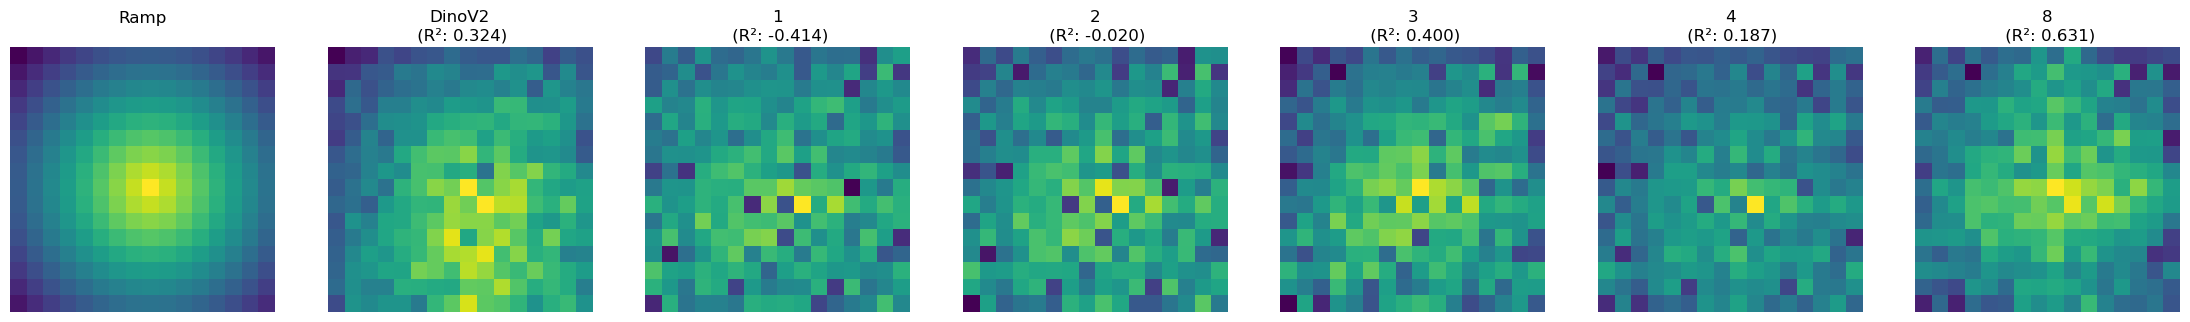

In [25]:
probe(preds, blanked, titles, ramp="radial", mask_step=2)

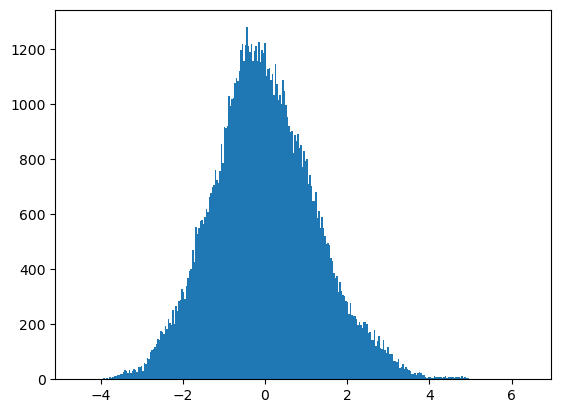

In [18]:
_ =plt.hist(preds[1].cpu().flatten(), bins=300)

In [17]:
torch.save(mean_res, "default_img_trans_mean_factor_4.pt")

NameError: name 'mean_res' is not defined

In [ ]:
import tifffile 
tifffile.imwrite("default_img_trans_mean_factor_4.tiff", mean_res.cpu().numpy())

NameError: name 'mean_res' is not defined